In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv("fixed_final_data.csv", low_memory=False)

df['completed'] = pd.to_datetime(df['completed'], errors='coerce')
df = df.dropna(subset=['completed'])

start_date = pd.Timestamp('2007-01-01')
end_date = pd.Timestamp('2026-02-28')

df = df[(df['completed'] >= start_date) & (df['completed'] <= end_date)]

df = df.set_index('completed')
df = df.sort_index()

In [145]:
ts = df.resample('ME').size()
ts = ts.to_frame(name='project_count')

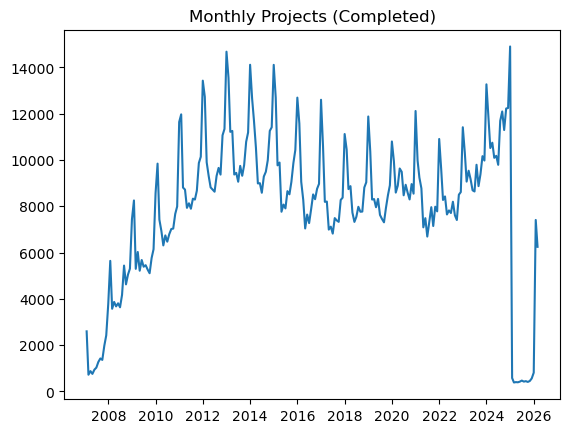

In [147]:
plt.figure()
plt.plot(ts)
plt.title("Monthly Projects (Completed)")
plt.show()

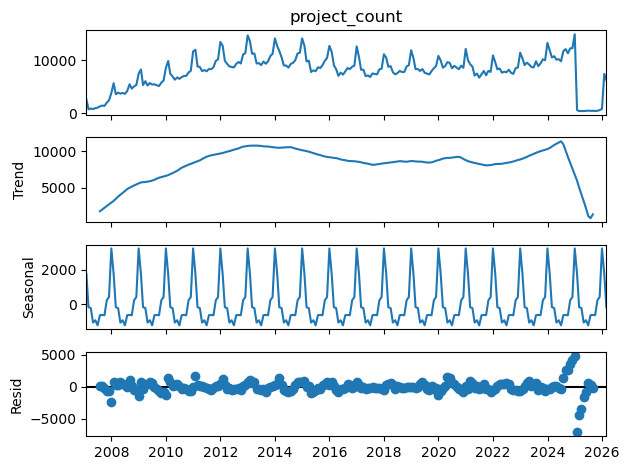

In [149]:
decomposition = seasonal_decompose(ts['project_count'], model='additive', period=12)

decomposition.plot()
plt.show()

In [151]:
cpi_raw = pd.read_csv("CPI.csv")

cpi_raw = cpi_raw.drop(columns=['HALF1', 'HALF2'], errors='ignore')

cpi_long = cpi_raw.melt(id_vars=['Year'], 
                       var_name='Month', 
                       value_name='CPI')

month_map = {
    'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
    'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12
}

cpi_long['Month'] = cpi_long['Month'].map(month_map)

cpi_long['DATE'] = pd.to_datetime(
    cpi_long[['Year','Month']].assign(DAY=1)
)

cpi = cpi_long.set_index('DATE').sort_index()

cpi = cpi[['CPI']]

cpi.index = cpi.index + pd.offsets.MonthEnd(0)

In [153]:
unemp_raw = pd.read_csv("unemployment_not_seasonaly_adj.csv")

unemp_long = unemp_raw.melt(
    id_vars=['Year'],
    var_name='Month',
    value_name='unemployment'
)

month_map = {
    'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
    'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12
}

unemp_long['Month'] = unemp_long['Month'].map(month_map)

unemp_long['DATE'] = pd.to_datetime(
    unemp_long[['Year','Month']].assign(DAY=1)
)

unemp = unemp_long.set_index('DATE').sort_index()

unemp = unemp[['unemployment']]

unemp.index = unemp.index + pd.offsets.MonthEnd(0)
unemp['unemployment'] = pd.to_numeric(unemp['unemployment'], errors='coerce')

In [155]:
ts = ts.join(cpi, how='inner')
ts = ts.join(unemp, how='inner')

ts = ts.asfreq('ME')
ts = ts.replace([np.inf, -np.inf], np.nan)
ts = ts.dropna()

In [157]:
model = SARIMAX(
    ts['project_count'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                      project_count   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -812.745
Date:                            Sun, 05 Apr 2026   AIC                           1635.490
Time:                                    13:55:27   BIC                           1648.153
Sample:                                         0   HQIC                          1640.603
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8929      0.319      2.796      0.005       0.267       1.519
ma.L1         -0.9672      0.251   

In [159]:
model_cpi = SARIMAX(
    ts['project_count'],
    exog=ts[['CPI']],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_cpi = model_cpi.fit()

print(results_cpi.summary())

C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                      project_count   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -813.704
Date:                            Sun, 05 Apr 2026   AIC                           1639.408
Time:                                    13:55:30   BIC                           1654.604
Sample:                                         0   HQIC                          1645.544
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CPI          -90.3628    255.861     -0.353      0.724    -591.841     411.116
ar.L1          0.2903      3.257   

In [161]:
model_unemp = SARIMAX(
    ts['project_count'],
    exog=ts[['unemployment']],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_unemp = model_unemp.fit()

print(results_unemp.summary())

C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                      project_count   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -811.675
Date:                            Sun, 05 Apr 2026   AIC                           1635.350
Time:                                    13:55:32   BIC                           1650.546
Sample:                                         0   HQIC                          1641.486
                                            - 120                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
unemployment     0.1152      0.270      0.426      0.670      -0.415       0.645
ar.L1            0.8824      

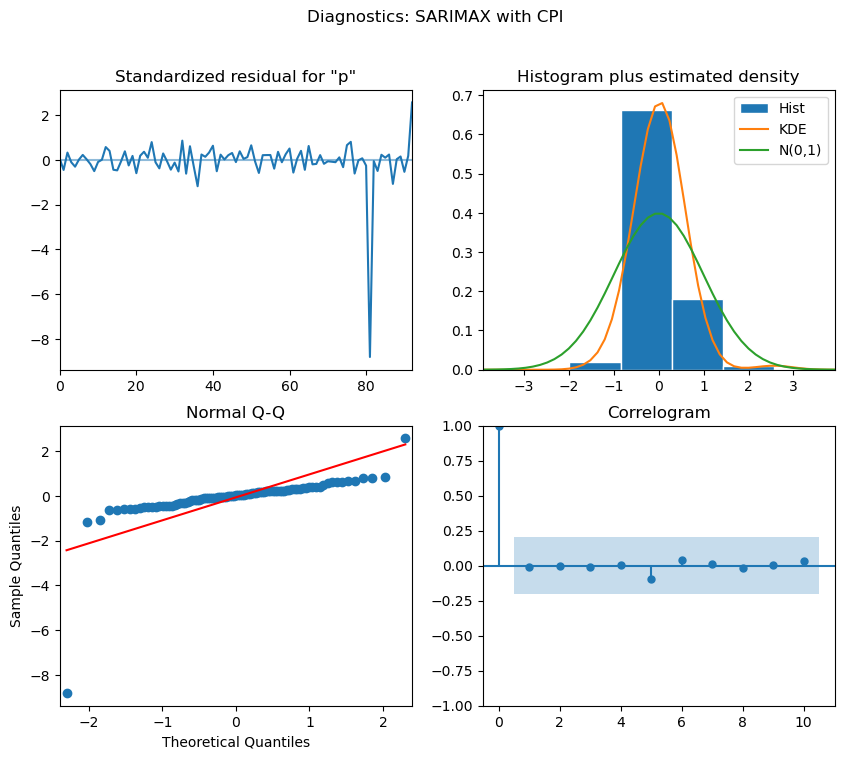

In [163]:
results_cpi.plot_diagnostics(figsize=(10,8))
plt.suptitle("Diagnostics: SARIMAX with CPI")
plt.show()

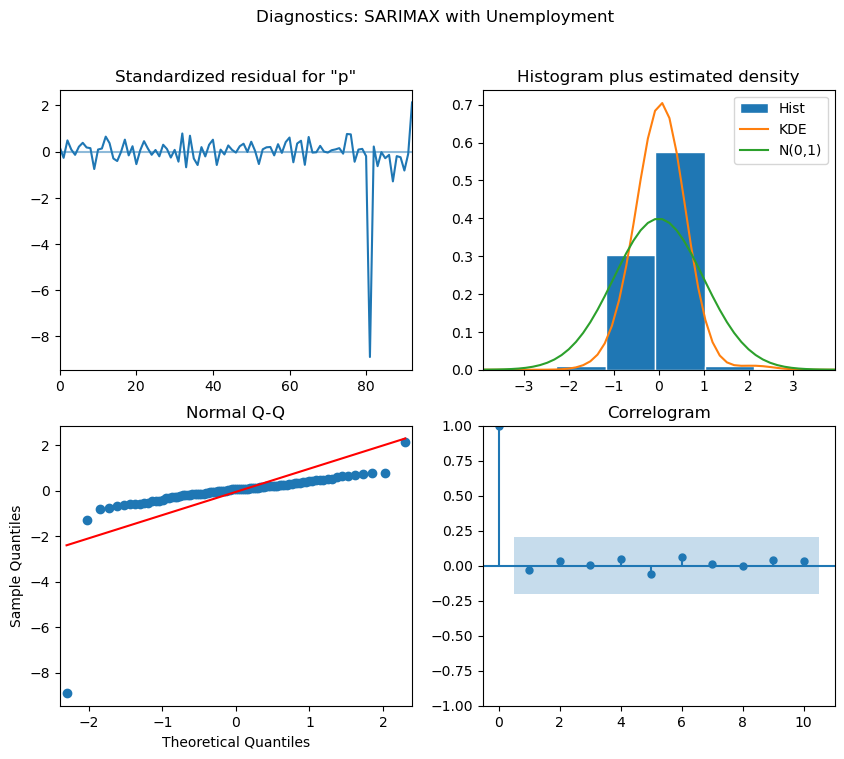

In [165]:
results_unemp.plot_diagnostics(figsize=(10,8))
plt.suptitle("Diagnostics: SARIMAX with Unemployment")
plt.show()

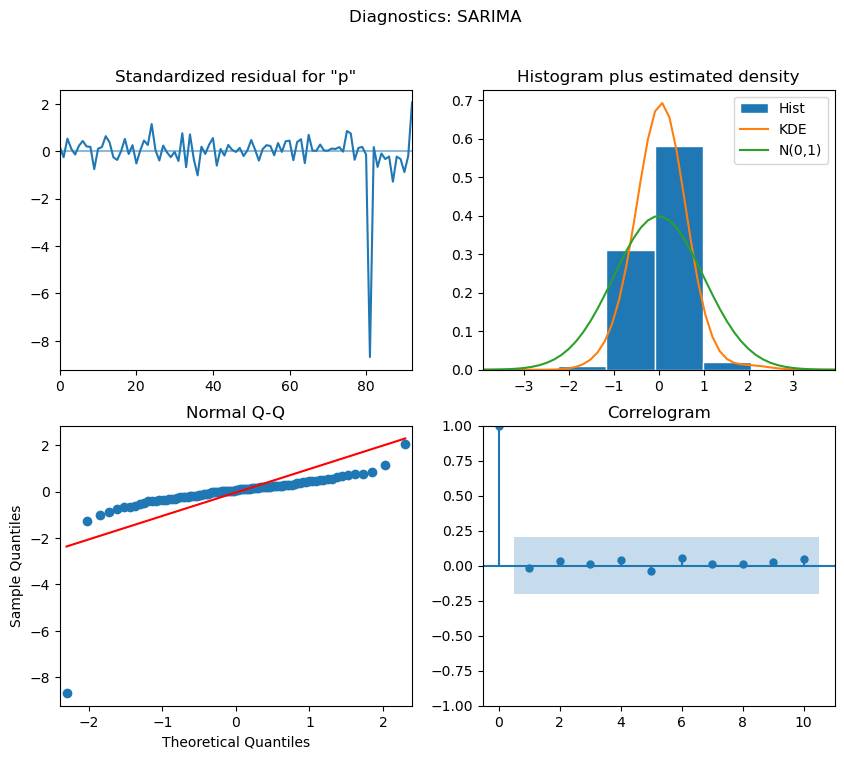

In [167]:
results.plot_diagnostics(figsize=(10,8))
plt.suptitle("Diagnostics: SARIMA")
plt.show()

In [175]:
forecast_steps = 12

forecast_base = results.get_forecast(steps=forecast_steps)
mean_base = forecast_base.predicted_mean
ci_base = forecast_base.conf_int()

C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [177]:
forecast_steps = 12
future_cpi = ts[['CPI']].iloc[-forecast_steps:]

forecast_cpi = results_cpi.get_forecast(
    steps=forecast_steps,
    exog=future_cpi
)

mean_cpi = forecast_cpi.predicted_mean
ci_cpi = forecast_cpi.conf_int()

C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [179]:
forecast_steps = 12
future_unemp = ts[['unemployment']].iloc[-forecast_steps:]

forecast_unemp = results_unemp.get_forecast(
    steps=forecast_steps,
    exog=future_unemp
)

mean_unemp = forecast_unemp.predicted_mean
ci_unemp = forecast_unemp.conf_int()

C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\miran\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [183]:
future_index = pd.date_range(
    start=ts.index[-1] + pd.offsets.MonthEnd(1),
    periods=forecast_steps,
    freq='ME'
)

mean_base.index = future_index
mean_cpi.index = future_index
mean_unemp.index = future_index

ci_base.index = future_index
ci_cpi.index = future_index
ci_unemp.index = future_index

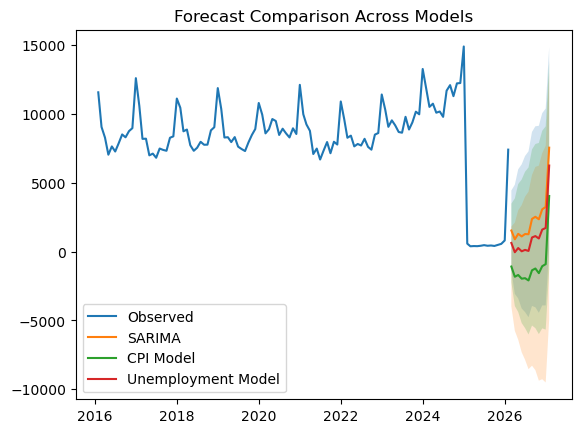

In [185]:
plt.figure()

plt.plot(ts['project_count'], label='Observed')

plt.plot(mean_base, label='SARIMA')
plt.plot(mean_cpi, label='CPI Model')
plt.plot(mean_unemp, label='Unemployment Model')

plt.fill_between(ci_base.index, ci_base.iloc[:,0], ci_base.iloc[:,1], alpha=0.2)
plt.fill_between(ci_cpi.index, ci_cpi.iloc[:,0], ci_cpi.iloc[:,1], alpha=0.2)
plt.fill_between(ci_unemp.index, ci_unemp.iloc[:,0], ci_unemp.iloc[:,1], alpha=0.2)

plt.legend()
plt.title("Forecast Comparison Across Models")
plt.show()